# **Dataset name: China-Africa Trade & Logistics Performance**

# **Source of the dataset:** https://www.kaggle.com/datasets/mjawad17/china-africa-trade-and-logistics-performance

In [1]:
# Install and import libraries

In [1]:
 !pip install --upgrade --force-reinstall fitter

  Using cached fitter-1.8.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached click-8.3.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached loguru-0.7.3-py3-none-any.whl.metadata (22 kB)
  Using cached matplotlib-3.10.8-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached numpy-2.4.4-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached pandas-3.0.2-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (79 kB)
  Using cached rich_click-1.9.7-py3-none-any.whl.metadata (8.7 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached contourpy-1.3.3-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-

In [2]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import PolynomialFeatures


plt.rcParams['image.cmap'] = 'bwr'
plt.rcParams['savefig.bbox'] = 'tight'
style.use('ggplot') or plt.style.use('ggplot')


import warnings
warnings.filterwarnings('ignore')

# **1. Define the problem: What do you want to predict? What data is available? Or what data do you need to obtain?**


# **Estimated shipping costs from China to Africa**


This dataset provides a comprehensive overview of trade dynamics between China and various African countries. It reflects the flow of essential commodities, focusing on the interrelationship between trade value, transportation logistics, and economic volatility.


# **Projec objective:**  
Develop a predictive model to optimize shipping costs on the China-Africa route by analyzing how the type of product (commodity) and weight (weight_kg) affect operational profitability, with the aim of identifying the most efficient routes and mitigating the impact of price volatility.


# **1. Data loading and initial exploration**

In [3]:
df = pd.read_excel('/content/drive/MyDrive/china_africa_trade.xlsx')

In [ ]:
df.head()

,shipment_id,export_country,import_country,commodity,hs_code,quantity,declared_value_usd,transport_mode,departure_port,arrival_port,transit_time_days,delay_status,contract_value_usd,payment_terms,currency_exchange_rate,market_price_per_unit,price_volatility_index,anomaly_flag,weight_kg,shipping_cost_usd
0,SHP00001,China,Nigeria,Electronics,260300,910,108694,Air,Guangzhou,Lagos,10,On-Time,109332,Credit,32.04,304.42,0.24,0,966.25,6736.40
1,SHP00002,China,Nigeria,Agricultural,260300,3494,21023,Road,Beijing,Tema,5,On-Time,20792,Credit,50.96,2815.97,0.01,0,16781.18,14027.25
2,SHP00003,China,South Africa,Machinery,847130,1234,90305,Road,Shenzhen,Durban,24,On-Time,90161,Credit,21.45,1837.50,0.08,0,48471.22,33014.01
3,SHP00004,China,Tanzania,Textiles,260300,2797,128855,Ship,Beijing,Mombasa,17,On-Time,128541,Credit,43.86,1150.47,0.49,1,1898.96,821.17
4,SHP00005,China,Tanzania,Minerals,847130,1578,16394,Road,Beijing,Lagos,39,On-Time,15414,On Delivery,32.36,44.73,0.47,1,11582.96,11702.20


In [ ]:
df.shape

(10000, 20)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   shipment_id             10000 non-null  object 
 1   export_country          10000 non-null  object 
 2   import_country          10000 non-null  object 
 3   commodity               10000 non-null  object 
 4   hs_code                 10000 non-null  int64  
 5   quantity                10000 non-null  int64  
 6   declared_value_usd      10000 non-null  int64  
 7   transport_mode          10000 non-null  object 
 8   departure_port          10000 non-null  object 
 9   arrival_port            10000 non-null  object 
 10  transit_time_days       10000 non-null  int64  
 11  delay_status            10000 non-null  object 
 12  contract_value_usd      10000 non-null  int64  
 13  payment_terms           10000 non-null  object 
 14  currency_exchange_rate  10000 non-null 

In [4]:
# Create a mirror table to preserve data integrity.
df_limpio = df.copy()

In [5]:
print("\n--- Updated descriptive statistics ---")
display(df.describe().round(3))


--- Updated descriptive statistics ---


,hs_code,quantity,declared_value_usd,transit_time_days,contract_value_usd,currency_exchange_rate,market_price_per_unit,price_volatility_index,anomaly_flag,weight_kg,shipping_cost_usd
count,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000,10000.000
mean,515246.679,2533.426,77879.336,21.084,77879.857,36.103,1509.629,0.254,0.272,23950.768,57536.143
std,301778.514,1424.921,41929.121,10.678,41932.575,19.691,870.258,0.142,0.445,38235.065,172307.702
min,100610.000,50.000,5015.000,3.000,4059.000,1.510,5.160,0.010,0.000,22.080,50.770
25%,260300.000,1302.500,41140.250,12.000,41162.750,18.998,757.288,0.130,0.000,2039.768,1743.938
50%,520942.000,2528.500,78072.500,21.000,78106.500,36.160,1511.835,0.250,0.000,6235.610,7484.370
75%,843890.000,3768.250,114186.750,30.000,114143.250,53.152,2266.160,0.380,1.000,29667.332,32553.933
max,847130.000,4999.000,149974.000,39.000,150809.000,69.990,2999.920,0.500,1.000,245179.160,2374780.440


In [6]:
# Select numeric columns
cols = df.select_dtypes(include=['float64', 'int64']).columns

outliers_dict = {}

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outliers_dict[col] = outliers.shape[0]

print(outliers_dict)

{'hs_code': 0, 'quantity': 0, 'declared_value_usd': 0, 'transit_time_days': 0, 'contract_value_usd': 0, 'currency_exchange_rate': 0, 'market_price_per_unit': 0, 'price_volatility_index': 0, 'anomaly_flag': 0, 'weight_kg': 1033, 'shipping_cost_usd': 1319}


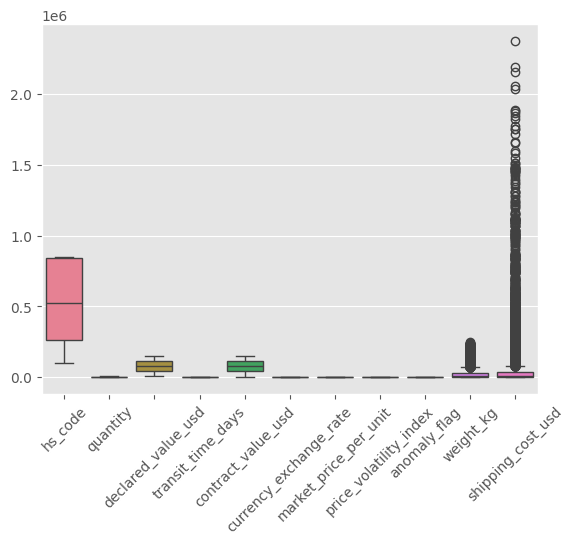

In [ ]:
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

In [8]:
# Create a copy so as not to alter the original
df_clean = df.copy()

for col in cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # Filter: to keep only what falls within the limits
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]

print(f"Original size: {df.shape}")
print(f"Size after cleaning: {df_clean.shape}")

Original size: (10000, 20)
Size after cleaning: (7879, 20)


# **2.	Explore and understand the data that will be used to create the model.**

•	Perform Exploratory Data Analysis (EDA) on qualitative and quantitative variables.


•	Generate a correlation matrix.


# **Categorical variables**

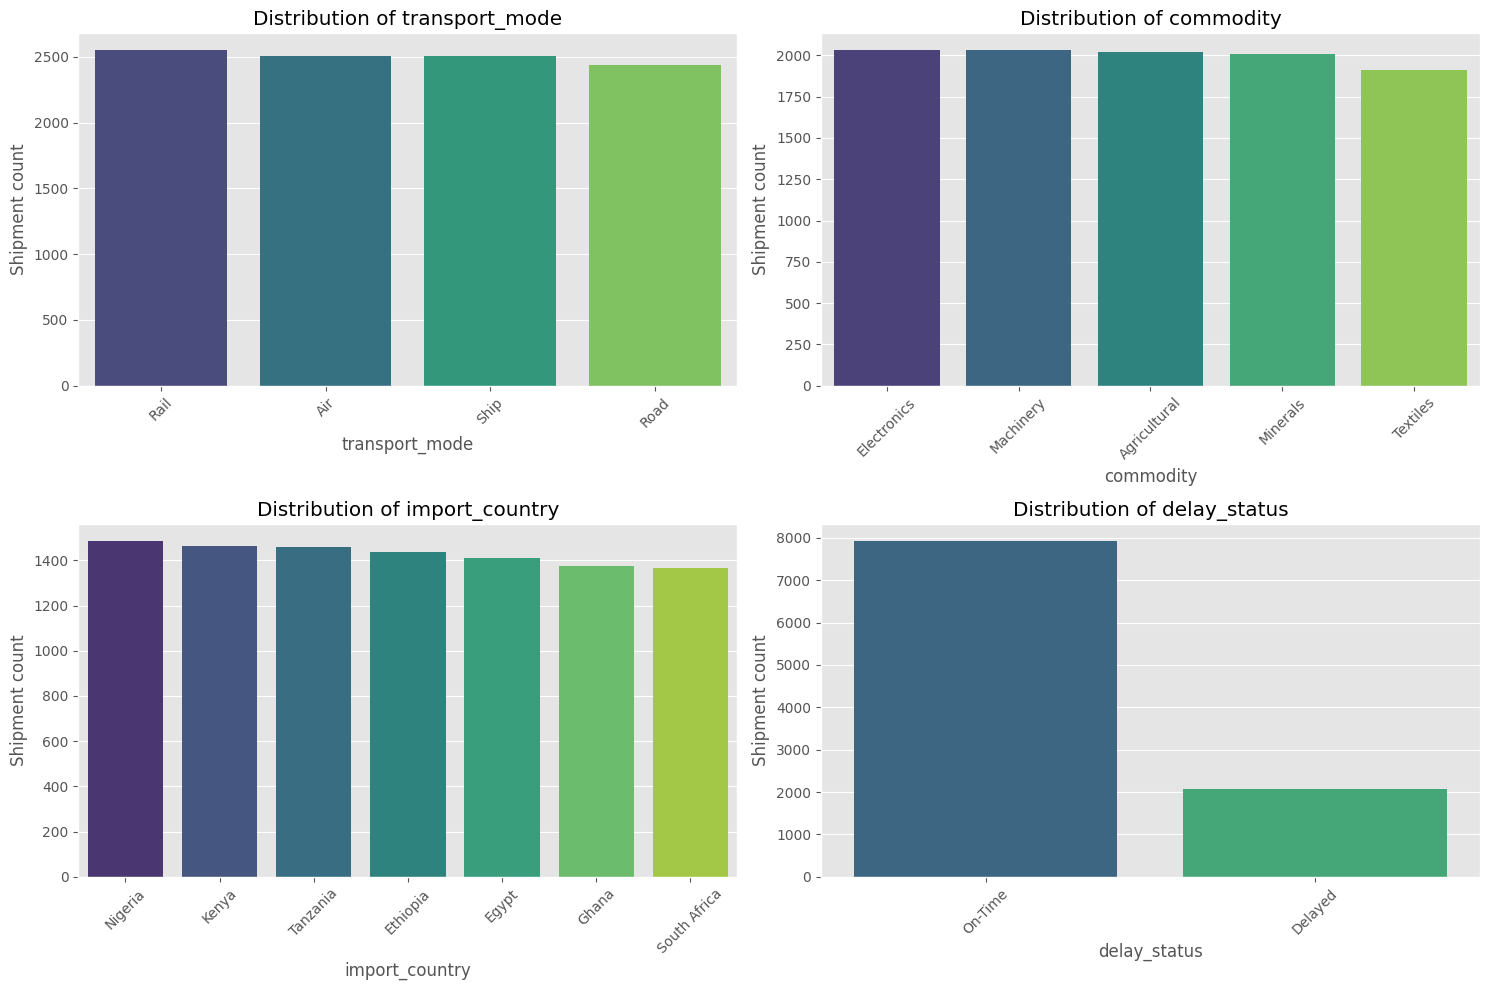


Frequencies fora transport_mode:
transport_mode
Rail    2551
Air     2507
Ship    2503
Road    2439
Name: count, dtype: int64

Frequencies fora commodity:
commodity
Electronics     2032
Machinery       2030
Agricultural    2018
Minerals        2010
Textiles        1910
Name: count, dtype: int64

Frequencies fora import_country:
import_country
Nigeria         1485
Kenya           1463
Tanzania        1458
Ethiopia        1439
Egypt           1410
Ghana           1377
South Africa    1368
Name: count, dtype: int64

Frequencies fora delay_status:
delay_status
On-Time    7921
Delayed    2079
Name: count, dtype: int64


In [9]:
# Key Categorical Variables
key_features = ['transport_mode', 'commodity', 'import_country', 'delay_status']

# Plot configuration
plt.figure(figsize=(15, 10))

for i, col in enumerate(key_features, 1):
    plt.subplot(2, 2, i)
    # Count the frequency of each category for plotting
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.ylabel('Shipment count')

plt.tight_layout()
plt.show()

for col in key_features:
    print(f"\nFrequencies fora {col}:")
    print(df[col].value_counts())

# **Correlation Analysis**
# Feature Correlation Matrix

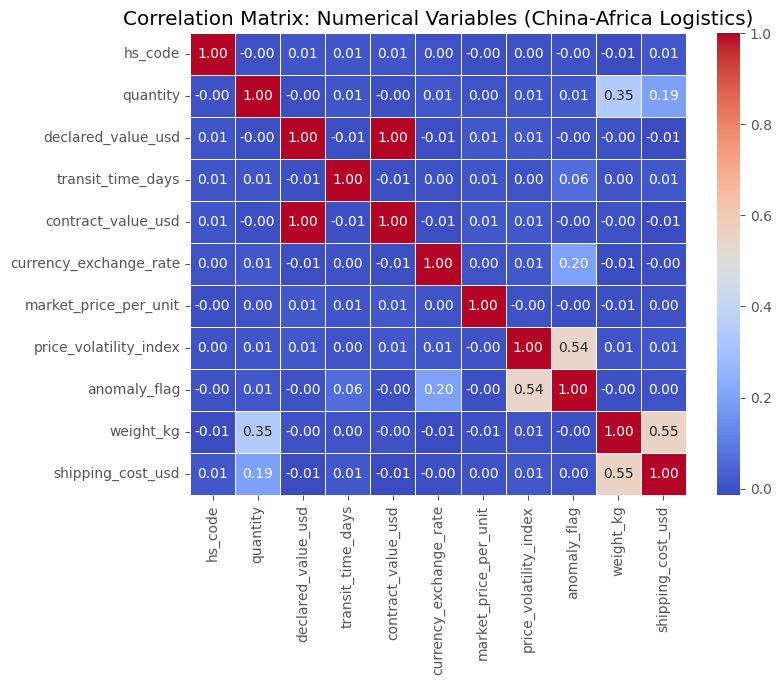

In [10]:
# 1. Select numerical variables only
df_numeric = df.select_dtypes(include=['number'])

# 2. Correlation Matrix Calculation
corr_matrix = df_numeric.corr()

# 3. Setup and plot the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix,
            annot=True,
            fmt=".2f",
            cmap='coolwarm',
            linewidths=0.5)

plt.title('Correlation Matrix: Numerical Variables (China-Africa Logistics)')
plt.show()

# **3.	Define model performance metrics**
# For this project, Mean Absolute Error (MAE) has been selected as the primary metric to evaluate model success.

# This choice is driven by the fact that MAE expresses the error in the same units as the target variable (USD), allowing for a direct interpretability of the results.

# By understanding the average deviation in monetary terms, it is possible to conduct a comparative analysis with other variables—such as delays or bureaucracy per country—to identify areas for operational improvement and optimize shipping cost resources more effectively.


# **4.	Split the dataset into training and testing sets**

In [11]:
from sklearn.model_selection import train_test_split

# Split the dataset
# X: Drop the target variable
# y: Select the target variable (shipping_cost_usd)

X_train, X_test, y_train, y_test = train_test_split(
    df.drop(['shipping_cost_usd', 'shipment_id'], axis='columns'),
    df.shipping_cost_usd,
    train_size=0.8,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

In [12]:

print('Data Partitioning Results (Shipping Costs)',
      '-------------------------------------------------------',
      y_train.describe(). round(3),
      '-------------------------------------------------------',
      sep='\n')

print('Testing Set Results (Shipping Costs)',
      '-------------------------------------------------------',
      y_test.describe(). round(3),
      '-------------------------------------------------------',
      sep='\n')

Data Partitioning Results (Shipping Costs)
-------------------------------------------------------
count       8000.000
mean       56419.696
std       168173.806
min           50.770
25%         1747.278
50%         7830.095
75%        33363.350
max      2188964.870
Name: shipping_cost_usd, dtype: float64
-------------------------------------------------------
Testing Set Results (Shipping Costs)
-------------------------------------------------------
count       2000.000
mean       62001.928
std       187914.951
min           64.820
25%         1739.163
50%         6404.170
75%        30069.338
max      2374780.440
Name: shipping_cost_usd, dtype: float64
-------------------------------------------------------


# **5.	Building an Integrated Preprocessing Pipeline:**


a. Missing value imputation


b. Standardization and scaling of numerical features

c. One-Hot Encoding of categorical variables



In [13]:
# 1. Identify numerical features (excluding the target variable)
numeric_columns = X_train.select_dtypes(include=np.number).columns.to_list()

# 2. Identify categorical features
categorical_columns = X_train.select_dtypes(include=['object', 'category']).columns.to_list()

print("Numerical Features:", numeric_columns)
print("Categorical Features:", categorical_columns)

Numerical Features: ['hs_code', 'quantity', 'declared_value_usd', 'transit_time_days', 'contract_value_usd', 'currency_exchange_rate', 'market_price_per_unit', 'price_volatility_index', 'anomaly_flag', 'weight_kg']
Categorical Features: ['export_country', 'import_country', 'commodity', 'transport_mode', 'departure_port', 'arrival_port', 'delay_status', 'payment_terms']


In [14]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# a & b: Numerical Preprocessing: Imputation and Scaling

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# a & c: Categorical Transformer
# Categorical Preprocessing: Frequent Imputation and One-Hot Encoding
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

In [15]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_columns),
        ('cat', categorical_transformer, categorical_columns)
    ],
    remainder='passthrough'
)

In [16]:
# Applying Data Transformations
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Extracting Feature Names from Preprocessor
encoded_features = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_columns)

# Concatenating numeric and encoded feature names
labels = np.concatenate([numeric_columns, encoded_features])

# Converting processed arrays back to Pandas DataFrame
df_train_processed = pd.DataFrame(X_train_processed, columns=labels)
df_test_processed = pd.DataFrame(X_test_processed, columns=labels)

# Verificar el resultado
print(df_train_processed.info())
df_train_processed.head()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 44 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   hs_code                      8000 non-null   float64
 1   quantity                     8000 non-null   float64
 2   declared_value_usd           8000 non-null   float64
 3   transit_time_days            8000 non-null   float64
 4   contract_value_usd           8000 non-null   float64
 5   currency_exchange_rate       8000 non-null   float64
 6   market_price_per_unit        8000 non-null   float64
 7   price_volatility_index       8000 non-null   float64
 8   anomaly_flag                 8000 non-null   float64
 9   weight_kg                    8000 non-null   float64
 10  export_country_China         8000 non-null   float64
 11  import_country_Egypt         8000 non-null   float64
 12  import_country_Ethiopia      8000 non-null   float64
 13  import_country_Ghana         

,hs_code,quantity,declared_value_usd,transit_time_days,contract_value_usd,currency_exchange_rate,market_price_per_unit,price_volatility_index,anomaly_flag,weight_kg,...,arrival_port_Dar es Salaam,arrival_port_Durban,arrival_port_Lagos,arrival_port_Mombasa,arrival_port_Tema,delay_status_Delayed,delay_status_On-Time,payment_terms_Credit,payment_terms_On Delivery,payment_terms_Prepaid
0,1.085554,0.438716,-1.368234,-1.504796,-1.376068,-1.196718,0.413264,-1.641068,-0.615496,0.740597,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
1,0.016436,-0.020593,0.706652,1.593907,0.699664,-1.294390,1.095257,1.724668,1.624707,-0.505008,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2,0.016436,0.284911,-1.241238,-1.316996,-1.252238,-0.844494,-1.394919,0.392398,-0.615496,-0.594109,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,1.096280,-1.567074,0.880098,-0.471895,0.863189,-1.147123,0.730198,0.742995,-0.615496,-0.626689,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,0.016436,-1.673824,0.829022,-0.284095,0.830241,0.235965,1.607242,0.813115,-0.615496,-0.574260,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


d. Parallel Feature Transformation with ColumnTransformer

e. Model Selection: Baseline Linear Regression

f. Model Evaluation Metrics


In [18]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_validate, RepeatedKFold

# 1. Building the Final Model Pipeline
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('estimator', Ridge())
])

# 2. Model Validation: Repeated K-Fold Cross-Validation
cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

# 3. Executing Model Evaluation & Performance Metrics

resultados_cv = cross_validate(
    estimator=pipe,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=('r2', 'neg_mean_absolute_error'),
    return_train_score=True,
    n_jobs=-1
)

# Consolidating Cross-Validation Results into a DataFrame
df_metrics_summary = pd.DataFrame(resultados_cv)

# Calculating Aggregate Performance Metrics
print(f"Average R-squared (R²): {df_metrics_summary['test_r2'].mean():.4f}")
print(f"Error Promedio (MAE): {abs(df_metrics_summary['test_neg_mean_absolute_error'].mean()):.2f} USD")

Average R-squared (R²): 0.4696
Error Promedio (MAE): 69932.97 USD


# **6.	Fine-tuning the model via Feature Expansion and Tuning**

In [20]:
import scipy.stats as stats
import inspect
from sklearn.model_selection import GridSearchCV

# ===============================================================================
# PART A: DISTRIBUTION DIAGNOSTICS & ANALYSIS
# ===============================================================================
data = y_train  # Target variable: Shipping costs
distribution = stats.norm
parameters = distribution.fit(data=data)

# Calculating AIC and BIC for Goodness-of-Fit justification
log_likelihood = distribution.logpdf(data.to_numpy(), *parameters).sum()
aic = -2 * log_likelihood + 2 * len(parameters)
bic = -2 * log_likelihood + np.log(data.shape[0]) * len(parameters)

print(f"Statistical Evaluation: Initial Distribution Fit (AIC/BIC): {aic:.2f}, BIC: {bic:.2f}")

# ===============================================================================
# PART B: HYPERPARAMETRER OPTIMIZATION & MODELTUNING
# ===============================================================================

# Defining the Pipeline

pipe_ridge = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

# Define the 'alpha' values for tuning (Hyperparameters)
param_grid = {'regressor__alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}

# Configure Grid Search to find the optimal hyperparameters
grid_ridge = GridSearchCV(
    estimator=pipe_ridge,
    param_grid=param_grid,
    cv=cv,
    scoring='r2',
    n_jobs=-1
)

# Execute the hyperparameter search and training
grid_ridge.fit(X_train, y_train)

print(f"Optimal Alpha Value: {grid_ridge.best_params_}")
print(f"Best Cross-Validated R² Score: {grid_ridge.best_score_:.4f}")

Statistical Evaluation: Initial Distribution Fit (AIC/BIC): 215230.07, BIC: 215244.04
Optimal Alpha Value: {'regressor__alpha': 10.0}
Best Cross-Validated R² Score: 0.4697


# **Enhancing Model Complexity via Polynomial Interactions**

In [21]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_validate, RepeatedKFold
import pandas as pd
import numpy as np

# 1. Defining the Pipeline with Polynomial Interactions
pipe_ridge_poly = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('interactions', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
    ('regressor', Ridge(alpha=10.0))
])

# 2. Configuring the Cross-Validation Strategy
cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)

# 3. Execute Multi-Metric Evaluation
print("Training Ridge model with interaction terms... (this may take a few seconds)")
results_poly = cross_validate(
    estimator=pipe_ridge_poly,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=('r2', 'neg_mean_absolute_error'),
    n_jobs=-1
)

# 4. Consolidate and Display Results
r2_final = results_poly['test_r2'].mean()
mae_final = abs(results_poly['test_neg_mean_absolute_error'].mean())
print("-" * 40)
print(f"RIDGE REGRESSION WITH INTERACTION TERMS")
print("-" * 40)
print(f"Average R² Score:         {r2_final:.4f}")
print(f"Average Error (MAE):      ${mae_final:.2f} USD")
print("-" * 40)

Training Ridge model with interaction terms... (this may take a few seconds)
----------------------------------------
RIDGE REGRESSION WITH INTERACTION TERMS
----------------------------------------
Average R² Score:         0.9556
Average Error (MAE):      $14954.82 USD
----------------------------------------


# **7.	Model Benchmarking Analysis**

# **Model 1: Decision Tree Regressor**

In [22]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# 1. Defining the Pipeline
pipe_tree = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

# 2. Hyperparameter Tuning: max_depth
grid_tree = GridSearchCV(
    pipe_tree,
    param_grid={'regressor__max_depth': [5, 10, 15, 20]},
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# 3. Model Training and Optimization
grid_tree.fit(X_train, y_train)

# 4. Reporting Best Performance
print(f"Best Decision Tree R² Score:   {grid_tree.best_score_:.4f}")
print(f"Optimal Tree Depth (max_depth): {grid_tree.best_params_}")

Best Decision Tree R² Score:   0.9543
Optimal Tree Depth (max_depth): {'regressor__max_depth': 5}


# **Model 2: Random forest**

In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# 1. Defining the Pipeline
pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

# 2. Hyperparameter Tuning: n_estimators
grid_rf = GridSearchCV(
    pipe_rf,
    param_grid={'regressor__n_estimators': [50, 100, 150]},
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# 3. Model Training and Optimization
grid_rf.fit(X_train, y_train)

# 4. Reporting Best Performance
print(f"Best Random Forest R² Score:   {grid_rf.best_score_:.4f}")
print(f"Optimal Number of Trees:       {grid_rf.best_params_}")

Best Random Forest R² Score:   0.9561
Optimal Number of Trees:       {'regressor__n_estimators': 150}


# **Model 3: KNN - K-Nearest Neighbors**

In [24]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

# 1. Defining the Pipeline
pipe_knn = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', KNeighborsRegressor())
])

# 2. Hyperparameter Tuning: n_neighbors (k-value)
grid_knn = GridSearchCV(
    pipe_knn,
    param_grid={'regressor__n_neighbors': [3, 5, 7, 11]},
    cv=5,
    scoring='r2',
    n_jobs=-1
)

# 3. Model Training and Optimization
grid_knn.fit(X_train, y_train)

# 4. Reporting Best Performance
print(f"Best KNN R² Score:         {grid_knn.best_score_:.4f}")
print(f"Optimal Number of Neighbors (k): {grid_knn.best_params_}")

Best KNN R² Score:         0.5273
Optimal Number of Neighbors (k): {'regressor__n_neighbors': 11}


# **Model Benchmarking**

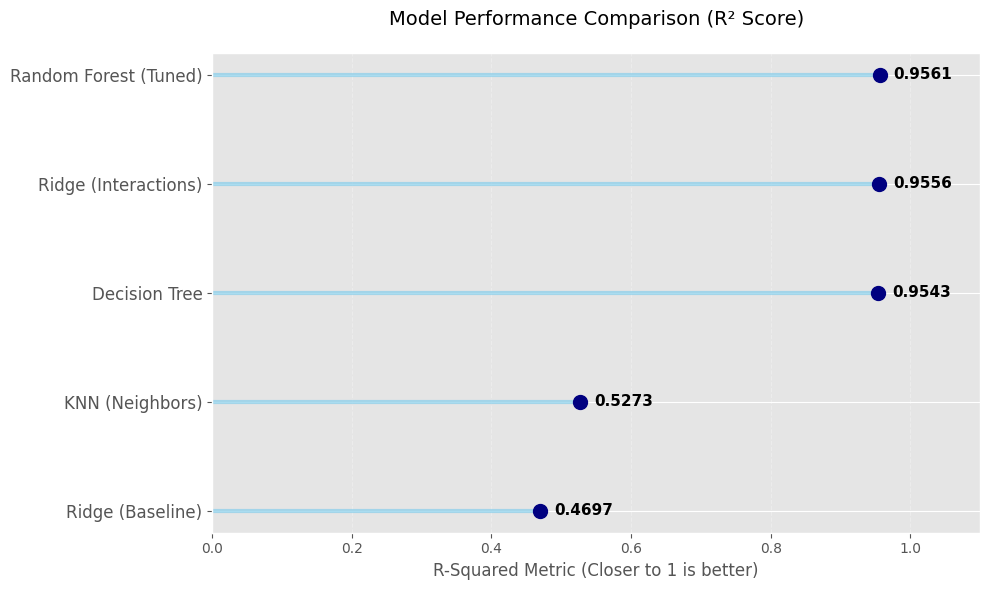

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create the DataFrame with your actual performance results
model_performance = pd.DataFrame({
    'model': [
        'Random Forest (Tuned)',
        'Ridge (Interactions)',
        'Decision Tree',
        'KNN (Neighbors)',
        'Ridge (Baseline)'
    ],
    'r2': [0.9561, 0.9556, 0.9543, 0.5273, 0.4697]
})

# 2. Sort by accuracy (lowest to highest for the chart layout)
model_performance = model_performance.sort_values('r2', ascending=True)

# 3. Create the visualization
fig, ax = plt.subplots(figsize=(10, 6))

# Draw the lines (hlines) and the marker points
ax.hlines(y=model_performance.model, xmin=0, xmax=model_performance.r2, color='skyblue', linewidth=3, alpha=0.7)
ax.plot(model_performance.r2, model_performance.model, 'o', markersize=10, color='navy')

# Add value labels next to each point for better readability
for i, value in enumerate(model_performance.r2):
    ax.text(value + 0.02, i, f'{value:.4f}', va='center', fontsize=11, fontweight='bold')

# Chart aesthetics and styling
ax.set_xlim(0, 1.1)  # Provide extra space for the text labels
ax.tick_params(axis='y', labelsize=12)
ax.set_title('Model Performance Comparison (R² Score)', fontsize=14, pad=20)
ax.set_xlabel('R-Squared Metric (Closer to 1 is better)', fontsize=12)
ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Final Prediction Comparison:
      Actual Value (USD)  Predicted Value (USD)  Difference (Error)
6252              998.81            1151.441867         -152.631867
4684             6031.00            4848.426867         1182.573133
1731             1352.05            2114.159267         -762.109267
4742             1254.07            1129.449533          124.620467
4521            15477.99           11992.343133         3485.646867
6340              513.33             842.305800         -328.975800
576              2371.65            1257.872733         1113.777267
5202             2029.74            2040.236800          -10.496800
6363              782.79             831.799067          -49.009067
439             11919.86           14403.299133        -2483.439133


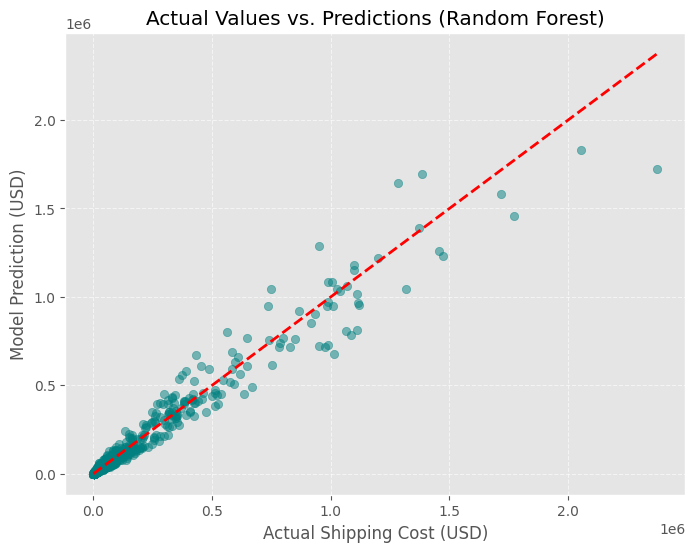

In [26]:
# 1. Use the best model (Tuned Random Forest) to predict the test set
y_pred = grid_rf.predict(X_test)

# 2. Create a DataFrame to compare Actual vs. Predicted values
comparison_df = pd.DataFrame({
    'Actual Value (USD)': y_test,
    'Predicted Value (USD)': y_pred,
    'Difference (Error)': y_test - y_pred
})

# 3. Display the first 10 rows to inspect performance
print("Final Prediction Comparison:")
print(comparison_df.head(10))

# 4. Scatter Plot: Actual vs. Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='teal')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Identity line
plt.title('Actual Values vs. Predictions (Random Forest)')
plt.xlabel('Actual Shipping Cost (USD)')
plt.ylabel('Model Prediction (USD)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# **8.	Efficiency review.**

# After conducting an exhaustive comparative analysis using cross-validation and hyperparameter tuning with GridSearchCV, several regression architectures were evaluated for cost prediction on the China-Africa route. The results obtained were:


# **Ridge Regression (Baseline):** The model showed poor performance with an R² of 0.4697 and a Mean Absolute Error (MAE) of $69,932. This highlighted that a simple linear structure is unable to capture the logistical complexity of the data. However, by implementing polynomial interactions, the model’s R² surged to 0.9556, proving that shipping costs depend on the synergistic relationship between variables (e.g., Weight vs. Transport Mode).

# **Decision Tree Regressor:** The model showed a drastic improvement with an R² of 0.9543 (using a max_depth of 5), successfully identifying non-linear patterns and clear decision rules within the data.

# **Random Forest Regressor:** Random Forest emerged as the most efficient and accurate model, achieving an R² of 0.9561 by utilizing an ensemble of 150 trees.

# **Model Selection & Final Verdict:** The Random Forest Regressor is selected as the winning model. Its ensemble architecture (bagging) offers the highest robustness and stability, reducing the prediction error to approximately $14,954. This level of precision provides a reliable tool for financial planning, allowing the organization to anticipate costs and optimize the profitability of its international operations.

# **9. Conclusions & Strategic Insights**

# Following the evaluation and tuning of various models, it is concluded that the complexity of logistics costs on the China-Africa route cannot be explained by simple linear models.


# The qualitative leap in accuracy (R²) from 0.46 to 0.95—achieved by applying polynomial interactions and ensemble models (Random Forest)—demonstrates that the final cost depends on the synergy between variables, particularly the relationship between cargo weight and the transportation method.

# **KEY FINDINGDS:**

# **Error Reduction Analysis:** the Mean Absolute Error (MAE) was successfully reduced from 69,932 dollars to 14,954 dollars. This improvement enables the organization to generate significantly more accurate financial forecasts, reducing uncertainty by 78%

# **Non-Linear Pattern Identification:** the poor performance of models such as KNN (0.52) compared to Random Forest (0.95) suggests the existence of 'cost jumps'—such as fixed rates and scale shifts per transport mode—that only tree-based models or interaction-aware architectures can effectively capture.

# **Efficiency of the Selected Model:** the implementation of Random Forest is recommended; with a configuration of 150 estimators, it provides the highest stability and generalization capability when processing new data.

# **Business impact:** this model empowers logistics management to predict shipping costs with high reliability, facilitating negotiations with carriers and route optimization. It ensures that weight and distance are managed under the most cost-effective transportation mode, as guided by the model’s predictive insights.